# LAISS — IsoForest + DiMMAD Scoring
Apply both anomaly models to objects extracted by the LAISS pipeline.

## 1. Imports & configuration

In [10]:
import numpy as np
import pandas as pd
from joblib import load
from pathlib import Path

FEATURES_CSV      = "lsst_extracted_features.csv"   # ← change to your TNS features file
ID_COL = "lsst_dia_object_id"                        # ← change to "Disc. Internal Name" 
                                                     #   (or whatever ID col your extracted features use)
# Paths
FEATURES_CSV      = "lsst_extracted_features.csv"          # LAISS output
ISOFOREST_MODEL   = "iforest_artifacts.joblib"              # IsoForest bundle
DIMMAD_MODEL      = "models/dimmad_medmed_relaiss_bundle.joblib"  # DiMMAD bundle
OUTPUT_CSV        = "laiss_anomaly_scores.csv"              # results file

3# ID column present in features CSV
ID_COL = "lsst_dia_object_id"   # change to "ZTFID" / "oid" etc. if needed
print("Config OK")

Config OK


## 2. Load features & models

In [12]:
# ── Features ──────────────────────────────────────────────────────────────────
df = pd.read_csv(FEATURES_CSV)
print(f"Loaded {len(df):,} objects  |  {df.shape[1]} columns")

# ── IsoForest artifacts ───────────────────────────────────────────────────────
iso_art  = load(ISOFOREST_MODEL)
iso      = iso_art["iso"]
knn_imp  = iso_art["knn_imp"]
iso_cols = iso_art["numeric_feature_cols"]
print(f"IsoForest  — {len(iso_cols)} features")

# ── DiMMAD artifacts ──────────────────────────────────────────────────────────
dim_art       = load(DIMMAD_MODEL)
dimmad_model  = dim_art["model"]
dimmad_imp    = dim_art["imputer"]
dimmad_scaler = dim_art["scaler"]
dimmad_cols   = dim_art["feature_cols"]
print(f"DiMMAD     — {len(dimmad_cols)} features")

Loaded 221 objects  |  84 columns


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


IsoForest  — 25 features
DiMMAD     — 25 features


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator IsolationForest from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KNNImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking

## 3. Isolation Forest scoring

In [14]:
# Fill any missing feature columns with NaN
for c in iso_cols:
    if c not in df.columns:
        df[c] = np.nan

X_iso     = df[iso_cols].replace([np.inf, -np.inf], np.nan)
X_iso_imp = knn_imp.transform(X_iso)

iso_scores  = iso.decision_function(X_iso_imp)   # higher = more normal
iso_pred    = iso.predict(X_iso_imp)             # −1 = anomaly
iso_anomaly = (iso_pred == -1).astype(int)       # 1 = anomaly

print(f"IsoForest anomaly rate : {iso_anomaly.mean():.3f}  ({iso_anomaly.sum()} flagged)")

IsoForest anomaly rate : 1.000  (221 flagged)


## 4. DiMMAD scoring

In [16]:
# Fill any missing feature columns with NaN
for c in dimmad_cols:
    if c not in df.columns:
        df[c] = np.nan

X_dim         = df[dimmad_cols].replace([np.inf, -np.inf], np.nan)
X_dim_imp     = dimmad_imp.transform(X_dim)
X_dim_scaled  = dimmad_scaler.transform(X_dim_imp)
dimmad_scores = dimmad_model.score_samples(X_dim_scaled)  # more negative = more anomalous

print(f"DiMMAD score range     : [{dimmad_scores.min():.3f}, {dimmad_scores.max():.3f}]")

DiMMAD score range     : [-0.877, -0.030]


## 5. Combine & rank results

In [18]:
results = pd.DataFrame({
    ID_COL:         df[ID_COL],
    # IsoForest — lower score = more anomalous → rank ascending
    "iso_score":    iso_scores,
    "iso_anomaly":  iso_anomaly,
    "iso_rank":     pd.Series(iso_scores).rank(method="first", ascending=True).astype(int),
    # DiMMAD — more negative = more anomalous → rank ascending
    "dimmad_score": dimmad_scores,
    "dimmad_rank":  pd.Series(dimmad_scores).rank(method="first", ascending=True).astype(int),
})

# Combined rank: average of both ranks (lower = more anomalous in both models)
results["combined_rank"] = (results["iso_rank"] + results["dimmad_rank"]) / 2

results.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(results):,} rows → {OUTPUT_CSV}")

Saved 221 rows → laiss_anomaly_scores.csv


## 6. Inspect top candidates

In [22]:
print("── Top 10 by IsoForest ──")
display(results.sort_values("iso_rank").head(10))

print("\n── Top 10 by DiMMAD ──")
display(results.sort_values("dimmad_rank").head(10))

print("\n── Top 10 by combined rank ──")
display(results.sort_values("combined_rank").head(10))

── Top 10 by IsoForest ──


,lsst_dia_object_id,iso_score,iso_anomaly,iso_rank,dimmad_score,dimmad_rank,combined_rank
186,313761042386124904,-0.201325,1,1,-0.256995,33,17.0
161,313897383783038984,-0.186324,1,2,-0.221555,71,36.5
31,313963359375458336,-0.184281,1,3,-0.248366,48,25.5
138,170028526789460018,-0.182080,1,4,-0.217894,74,39.0
41,170028485783322694,-0.181429,1,5,-0.232494,58,31.5
3,313853517475348486,-0.180123,1,6,-0.120741,185,95.5
140,170028527011758122,-0.178337,1,7,-0.231662,60,33.5
210,313853517574963301,-0.177475,1,8,-0.128107,176,92.0
195,313871013678940198,-0.177415,1,9,-0.126381,179,94.0
83,170032906681450641,-0.177347,1,10,-0.226902,63,36.5



── Top 10 by DiMMAD ──


,lsst_dia_object_id,iso_score,iso_anomaly,iso_rank,dimmad_score,dimmad_rank,combined_rank
34,170028486327533675,-0.139293,1,131,-0.877375,1,66.0
105,313963406094237721,-0.145928,1,113,-0.747791,2,57.5
66,170028486178635819,-0.121960,1,152,-0.492371,3,77.5
14,170028492511510705,-0.120690,1,154,-0.451607,4,79.0
122,170028535923081252,-0.160738,1,27,-0.447784,5,16.0
145,170028528620273678,-0.066326,1,213,-0.446024,6,109.5
144,170028528545300647,-0.164103,1,21,-0.442320,7,14.0
91,170028511771230587,-0.078825,1,198,-0.441932,8,103.0
124,170032922922844339,-0.080533,1,194,-0.437935,9,101.5
204,313928194426667064,-0.100492,1,178,-0.422433,10,94.0



── Top 10 by combined rank ──


,lsst_dia_object_id,iso_score,iso_anomaly,iso_rank,dimmad_score,dimmad_rank,combined_rank
144,170028528545300647,-0.164103,1,21,-0.442320,7,14.0
122,170028535923081252,-0.160738,1,27,-0.447784,5,16.0
186,313761042386124904,-0.201325,1,1,-0.256995,33,17.0
108,313972182945890309,-0.159543,1,30,-0.420707,11,20.5
82,170032905875619955,-0.162060,1,26,-0.362246,19,22.5
31,313963359375458336,-0.184281,1,3,-0.248366,48,25.5
10,170028485844664382,-0.159042,1,33,-0.329114,24,28.5
80,170046089928376424,-0.160297,1,29,-0.277960,29,29.0
41,170028485783322694,-0.181429,1,5,-0.232494,58,31.5
140,170028527011758122,-0.178337,1,7,-0.231662,60,33.5


## 7. (Optional) Agreement between models

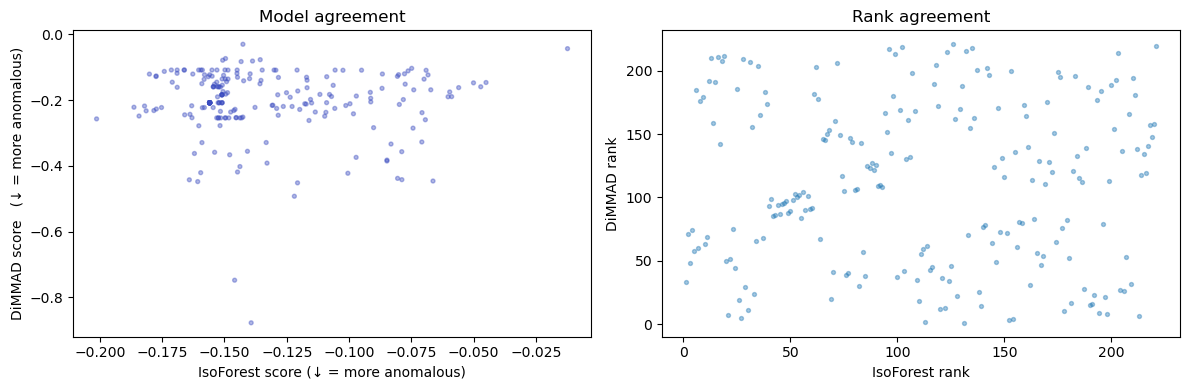

Score correlation: -0.021


In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score–score scatter
ax = axes[0]
ax.scatter(results["iso_score"], results["dimmad_score"],
           alpha=0.4, s=8, c=results["iso_anomaly"],
           cmap="coolwarm")
ax.set_xlabel("IsoForest score (↓ = more anomalous)")
ax.set_ylabel("DiMMAD score   (↓ = more anomalous)")
ax.set_title("Model agreement")

# Rank–rank scatter
ax = axes[1]
ax.scatter(results["iso_rank"], results["dimmad_rank"],
           alpha=0.4, s=8)
ax.set_xlabel("IsoForest rank")
ax.set_ylabel("DiMMAD rank")
ax.set_title("Rank agreement")

plt.tight_layout()
plt.show()

corr = results[["iso_score", "dimmad_score"]].corr().iloc[0, 1]
print(f"Score correlation: {corr:.3f}")